# Post-Training Evaluation: Track A (Clean) vs Track B (Mixed)

This notebook covers **only post-training evaluation** of the RLAD noise-control experiment on Hendrycks MATH (Qwen3-1.7B):

- **Track A (clean):** trained on standard Hendrycks MATH data.
- **Track B (mixed):** trained on Hendrycks MATH with prepended trivia facts.

Both tracks are evaluated at the final **step 400** checkpoint on the **MATH-500** test set using a dedicated 32-sample-per-question eval (`scripts/run_pass32_sweep_1p7_hendrycks.sh`).

It contains two analyses:
1. **Semantic solution diversity** (Section 10) — how varied the 32 solutions per question are, measured with `Qwen/Qwen3-Embedding-4B`.
2. **Pass@k sampling-budget comparison** (Section 11) — unbiased pass@k for `k in {1,2,4,8,16,32}`.

All input artifacts are downloaded from the Modal volume `e3-generation-vol`. We assume the diversity computation (`modal_compute_diversity_hendrycks.py`) has already been run and its `embedding_diversity_results.csv` exists on the volume.

In [1]:
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 10. Semantic Solution Diversity (Qwen3-Embedding-4B)

Beyond accuracy, we want to know whether each track explores *diverse reasoning paths* or converges to a narrow set of strategies. We measure this by computing the semantic similarity among all 32 generated solutions for a given question within each track.

**Method:**
1. For each of 100 randomly sampled MATH-500 test questions, extract all 32 response strings from the pass@32 eval parquets (step 400).
2. Encode each response into a normalized embedding vector using `Qwen/Qwen3-Embedding-4B`.
3. Compute pairwise cosine similarity between all `(32 × 31) / 2 = 496` unique pairs of embeddings per question.
4. Average those 496 similarities to get one "mean intra-question similarity" score per question.
5. Compare the distribution of these scores between Track A and Track B.

**Interpretation:** A *higher* mean similarity means the 32 solutions are semantically very similar to each other (low diversity — the model has settled on a few reasoning templates). A *lower* mean similarity means the solutions vary more in their reasoning (high diversity — the model explores more varied strategies).

**Scope:** We compute similarity *within* each track only (Track A's solutions compared to Track A's, Track B's compared to Track B's). The same 100 questions are used for both tracks to ensure a fair comparison. All 32 responses per question are used, regardless of correctness.

The underlying computation runs on a Modal GPU instance (`modal_compute_diversity_hendrycks.py`); here we assume it has already run and simply download the resulting CSV.

In [2]:
# Download the diversity results from the Modal volume (skip if present).
DIVERSITY_DIR = "diversity_1p7b_hendrycks"
os.makedirs(DIVERSITY_DIR, exist_ok=True)

remote_csv = "diversity_1p7b_hendrycks/embedding_diversity_results.csv"
local_csv = os.path.join(DIVERSITY_DIR, "embedding_diversity_results.csv")

if not os.path.exists(local_csv):
    print(f"Downloading {remote_csv} from Modal volume 'e3-generation-vol'...")
    result = subprocess.run(
        ["modal", "volume", "get", "e3-generation-vol", remote_csv],
        capture_output=True, text=True, cwd=DIVERSITY_DIR,
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr)
        raise RuntimeError("Failed to download diversity results")
    print("Download complete.")
else:
    print(f"{local_csv} already present locally.")

assert os.path.exists(local_csv), f"Missing: {local_csv}"
print(f"OK: {local_csv} ({os.path.getsize(local_csv)} bytes)")

diversity_1p7b_hendrycks/embedding_diversity_results.csv already present locally.
OK: diversity_1p7b_hendrycks/embedding_diversity_results.csv (9927 bytes)


=== Mean Intra-Question Similarity (lower = more diverse) ===
Track A (Clean): mean=0.9766  std=0.0166  min=0.9217  max=0.9969  n=100
Track B (Mixed): mean=0.9769  std=0.0170  min=0.9169  max=0.9959  n=100

Welch's t-test: t=-0.1146, p=9.0890e-01
No statistically significant difference in solution diversity (p>=0.05).


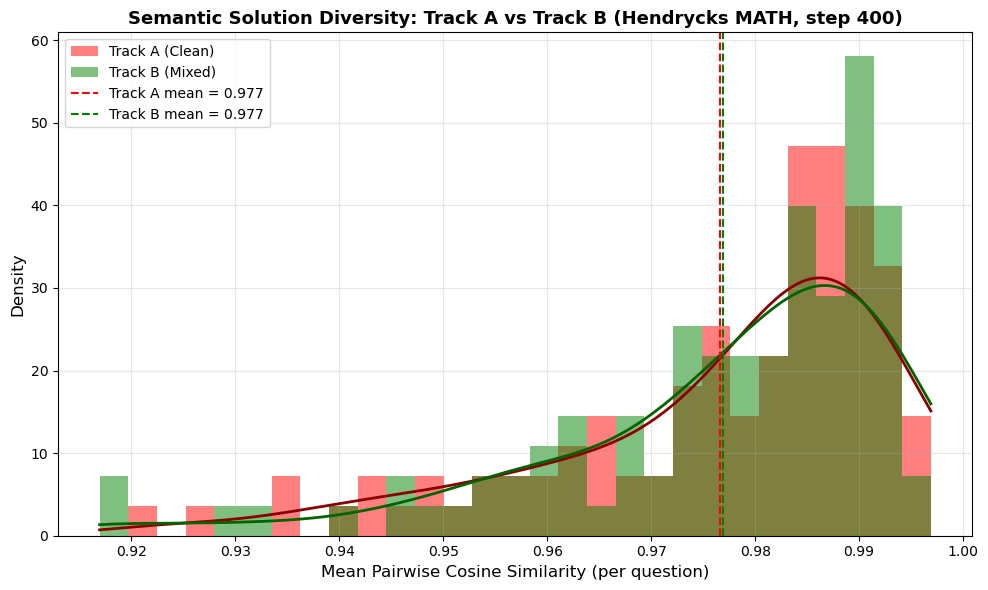


Saved figure -> 1p7b_hendrycks_embedding_diversity.png


In [3]:
# Load the diversity results
df_div = pd.read_csv(os.path.join("diversity_1p7b_hendrycks", "embedding_diversity_results.csv"))

div_a = df_div[df_div["track"] == "A"]["mean_similarity"]
div_b = df_div[df_div["track"] == "B"]["mean_similarity"]

print("=== Mean Intra-Question Similarity (lower = more diverse) ===")
print(f"Track A (Clean): mean={div_a.mean():.4f}  std={div_a.std():.4f}  "
      f"min={div_a.min():.4f}  max={div_a.max():.4f}  n={len(div_a)}")
print(f"Track B (Mixed): mean={div_b.mean():.4f}  std={div_b.std():.4f}  "
      f"min={div_b.min():.4f}  max={div_b.max():.4f}  n={len(div_b)}")

# Welch's t-test (does not assume equal variance)
t_stat, p_val = stats.ttest_ind(div_a, div_b, equal_var=False)
print(f"\nWelch's t-test: t={t_stat:.4f}, p={p_val:.4e}")
if p_val < 0.05:
    more_diverse = "Track A" if div_a.mean() < div_b.mean() else "Track B"
    print(f"Statistically significant difference (p<0.05). {more_diverse} has MORE diverse solutions.")
else:
    print("No statistically significant difference in solution diversity (p>=0.05).")

# Plot overlapping density histograms
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(
    min(div_a.min(), div_b.min()),
    max(div_a.max(), div_b.max()),
    30,
)
ax.hist(div_a, bins=bins, alpha=0.5, color="red", density=True, label="Track A (Clean)")
ax.hist(div_b, bins=bins, alpha=0.5, color="green", density=True, label="Track B (Mixed)")

# Density curves (KDE)
for data, color in [(div_a, "darkred"), (div_b, "darkgreen")]:
    kde = stats.gaussian_kde(data)
    xs = np.linspace(bins[0], bins[-1], 200)
    ax.plot(xs, kde(xs), color=color, linewidth=2)

# Mean lines
ax.axvline(div_a.mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Track A mean = {div_a.mean():.3f}")
ax.axvline(div_b.mean(), color="green", linestyle="--", linewidth=1.5,
           label=f"Track B mean = {div_b.mean():.3f}")

ax.set_xlabel("Mean Pairwise Cosine Similarity (per question)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Semantic Solution Diversity: Track A vs Track B (Hendrycks MATH, step 400)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("1p7b_hendrycks_embedding_diversity.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved figure -> 1p7b_hendrycks_embedding_diversity.png")

In [4]:
# Divergence spot-check: which questions show the biggest gap in diversity
# between the two tracks?
pivot = df_div.pivot(index="question_idx", columns="track", values="mean_similarity")
pivot = pivot.dropna()
pivot.columns = ["sim_a", "sim_b"]

# delta = sim_b - sim_a.
#   delta < 0  => Track B more similar (less diverse) than Track A here
#   delta > 0  => Track A more similar (less diverse) than Track B here
pivot["delta"] = pivot["sim_b"] - pivot["sim_a"]

print("=== Questions where Track B is MOST diverse relative to Track A ===")
print("(largest negative delta: Track B solutions much less similar to each other)")
top_b_diverse = pivot.sort_values("delta").head(3)
print(top_b_diverse.to_string())

print("\n=== Questions where Track A is MOST diverse relative to Track B ===")
print("(largest positive delta: Track A solutions much less similar to each other)")
top_a_diverse = pivot.sort_values("delta", ascending=False).head(3)
print(top_a_diverse.to_string())

=== Questions where Track B is MOST diverse relative to Track A ===
(largest negative delta: Track B solutions much less similar to each other)
                 sim_a     sim_b     delta
question_idx                              
332           0.956968  0.918493 -0.038475
302           0.946051  0.916950 -0.029101
412           0.976858  0.952603 -0.024256

=== Questions where Track A is MOST diverse relative to Track B ===
(largest positive delta: Track A solutions much less similar to each other)
                 sim_a     sim_b     delta
question_idx                              
454           0.940342  0.973603  0.033261
483           0.964698  0.991048  0.026350
36            0.942525  0.958453  0.015929


## 11. Pass@k Sampling-Budget Comparison (up to pass@32)

To study how each track scales with a larger sampling budget, we ran a dedicated evaluation that generates **32 samples per question** on the full MATH-500 test set for the final (step 400) checkpoint of both tracks (see `scripts/run_pass32_sweep_1p7_hendrycks.sh`).

Each eval writes a `per_problem_*.csv` (with `n_correct` out of `n_samples=32` per question). From those counts we compute the **unbiased pass@k estimator** (Chen et al., HumanEval) for `k in {1, 2, 4, 8, 16, 32}` and compare Track A (clean) vs Track B (mixed).

Only the **step 400** checkpoint was evaluated with 32 samples, so this is a single-checkpoint comparison.

In [5]:
# Download the 32-sample per-problem eval CSVs from the Modal volume (skip if present).
# These are produced by scripts/run_pass32_sweep_1p7_hendrycks.sh and live under
# /data/pass32_1p7b_hendrycks/ on volume 'e3-generation-vol'.
PASS_DIR = "pass32_1p7b_hendrycks"   # local cache
PASS_STEPS = [400]
KS = [1, 2, 4, 8, 16, 32]
os.makedirs(PASS_DIR, exist_ok=True)


def remote_csv_name(track, step):
    return f"per_problem_math_{track}_hendrycks_step{step}.csv"


missing = []
for track in ("track_a", "track_b"):
    for step in PASS_STEPS:
        fname = remote_csv_name(track, step)
        local_path = os.path.join(PASS_DIR, fname)
        if not os.path.exists(local_path):
            missing.append((fname, local_path))

if missing:
    print(f"Downloading {len(missing)} eval CSVs from Modal volume 'e3-generation-vol'...")
    for fname, local_path in missing:
        remote_path = f"pass32_1p7b_hendrycks/{fname}"
        cmd = ["modal", "volume", "get", "e3-generation-vol", remote_path]
        print(f"  {remote_path} -> {local_path}")
        result = subprocess.run(cmd, capture_output=True, text=True, cwd=PASS_DIR)
        if result.returncode != 0:
            print(f"  ERROR: {result.stderr.strip()}")
            raise RuntimeError(f"Failed to download {remote_path}. Has the sweep finished?")
    print("Download complete.")
else:
    print("All pass@k eval CSVs already present locally.")

# Verify presence
for track in ("track_a", "track_b"):
    for step in PASS_STEPS:
        p = os.path.join(PASS_DIR, remote_csv_name(track, step))
        assert os.path.exists(p), f"Missing: {p}"
print("All pass@k eval CSVs ready.")

All pass@k eval CSVs already present locally.
All pass@k eval CSVs ready.


In [6]:
# Compute the unbiased pass@k for k in {1,2,4,8,16,32} from per-problem n_correct.
def pass_at_k(n, c, k):
    """Unbiased pass@k estimator (Chen et al., HumanEval).

    n = samples per question, c = number correct, k = budget.
    Probability that at least one of k drawn samples is correct.
    """
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))


rows = []
for track_label, track_key in (("A", "track_a"), ("B", "track_b")):
    for step in PASS_STEPS:
        df = pd.read_csv(os.path.join(PASS_DIR, remote_csv_name(track_key, step)))
        n_samples = int(df["n_samples"].iloc[0])
        num_problems = len(df)
        for k in KS:
            vals = [pass_at_k(int(r.n_samples), int(r.n_correct), k) for r in df.itertuples()]
            rows.append({
                "track": track_label,
                "step": step,
                "k": k,
                "pass_at_k": float(np.mean(vals)),
                "n_samples": n_samples,
                "num_problems": num_problems,
            })

df_passk = pd.DataFrame(rows)

# Sanity check: pass@k must be non-decreasing in k for each (track, step).
for (t, s), g in df_passk.groupby(["track", "step"]):
    g = g.sort_values("k")
    assert (g["pass_at_k"].diff().dropna() >= -1e-9).all(), f"pass@k not monotonic for track {t} step {s}"

print(f"Computed pass@k for {df_passk[['track','step']].drop_duplicates().shape[0]} (track, step) pairs.")
print(f"Samples per question: {sorted(df_passk['n_samples'].unique())}, "
      f"problems: {sorted(df_passk['num_problems'].unique())}")
df_passk

Computed pass@k for 2 (track, step) pairs.
Samples per question: [32], problems: [500]


,track,step,k,pass_at_k,n_samples,num_problems
0,A,400,1,0.756563,32,500
1,A,400,2,0.800431,32,500
2,A,400,4,0.827609,32,500
3,A,400,8,0.847641,32,500
4,A,400,16,0.865000,32,500
5,A,400,32,0.880000,32,500
6,B,400,1,0.761125,32,500
7,B,400,2,0.808524,32,500
8,B,400,4,0.840596,32,500
9,B,400,8,0.862874,32,500


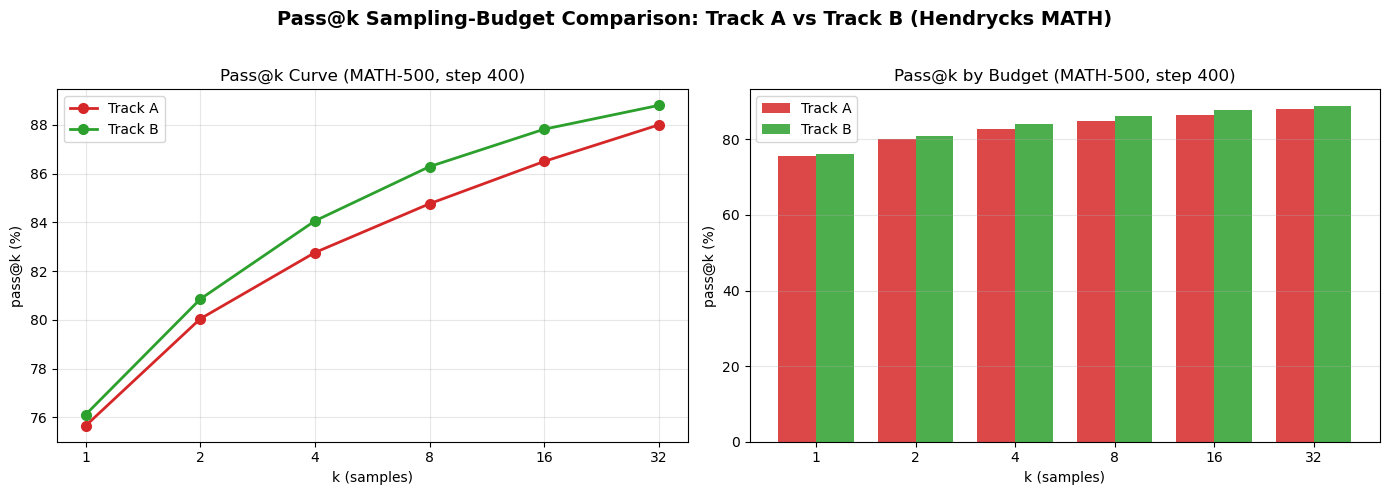

In [7]:
# Pass@k curves at step 400: Track A vs Track B.
colors = {"A": "#d62728", "B": "#2ca02c"}
step = 400

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: line plot of pass@k vs k
ax = axes[0]
for label in ("A", "B"):
    d = df_passk[(df_passk["track"] == label) & (df_passk["step"] == step)].sort_values("k")
    ax.plot(d["k"], d["pass_at_k"] * 100, "o-", color=colors[label],
            linewidth=2, markersize=7, label=f"Track {label}")
ax.set_xscale("log", base=2)
ax.set_xticks(KS)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("k (samples)")
ax.set_ylabel("pass@k (%)")
ax.set_title(f"Pass@k Curve (MATH-500, step {step})")
ax.grid(True, alpha=0.3)
ax.legend()

# Right: grouped bar chart of pass@k by k
ax = axes[1]
x = np.arange(len(KS))
width = 0.38
for i, label in enumerate(("A", "B")):
    d = df_passk[(df_passk["track"] == label) & (df_passk["step"] == step)].sort_values("k")
    ax.bar(x + (i - 0.5) * width, d["pass_at_k"].values * 100, width,
           color=colors[label], alpha=0.85, label=f"Track {label}")
ax.set_xticks(x)
ax.set_xticklabels(KS)
ax.set_xlabel("k (samples)")
ax.set_ylabel("pass@k (%)")
ax.set_title(f"Pass@k by Budget (MATH-500, step {step})")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()

plt.suptitle("Pass@k Sampling-Budget Comparison: Track A vs Track B (Hendrycks MATH)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("1p7b_hendrycks_pass_at_k.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Summary table: pass@k columns x track rows, plus A-vs-B gap at pass@32.
pivot = (
    df_passk
    .pivot_table(index=["step", "track"], columns="k", values="pass_at_k")
    .mul(100)
    .round(2)
)
pivot.columns = [f"pass@{k}" for k in pivot.columns]

pivot.to_csv("1p7b_hendrycks_pass_at_k.csv")
print("Saved pass@k table to 1p7b_hendrycks_pass_at_k.csv\n")
print(pivot)

# Gap at pass@32 (Track B - Track A) in percentage points.
gap = (
    df_passk[df_passk["k"] == 32]
    .pivot_table(index="step", columns="track", values="pass_at_k")
    .mul(100)
)
gap["gap_B_minus_A"] = (gap["B"] - gap["A"]).round(2)
print("\npass@32 gap (Track B - Track A), percentage points:")
print(gap["gap_B_minus_A"])

Saved pass@k table to 1p7b_hendrycks_pass_at_k.csv

            pass@1  pass@2  pass@4  pass@8  pass@16  pass@32
step track                                                  
400  A       75.66   80.04   82.76   84.76    86.50     88.0
     B       76.11   80.85   84.06   86.29    87.82     88.8

pass@32 gap (Track B - Track A), percentage points:
step
400    0.8
Name: gap_B_minus_A, dtype: float64


## 12. Per-Question Pass@1 Spot-Check (step 400)

Sections 10 and 11 are aggregate. Here we inspect *individual* MATH-500 questions to qualitatively compare how Track A (clean) and Track B (mixed) answer, in the spirit of Section 8 of the original notebook.

We reuse the **same step-400 pass@32 outputs** that back Section 10 (`math_track_{a,b}_hendrycks_step400_outputs.parquet`). For each question we define **pass@1** as the **first of the 32 generated samples** (`responses[0]`), scored with the verl MATH scorer (`\boxed{}` extraction + SymPy-style equivalence). The answer we display is exactly the sample we score.

Three spot-checks (each picks a *random* qualifying question; re-run a cell to draw another):
1. Track B pass@1 **correct**, Track A pass@1 **incorrect**.
2. Track A pass@1 **correct**, Track B pass@1 **incorrect**.
3. **Both** tracks pass@1 **incorrect**.

In [9]:
# Download the step-400 pass@32 OUTPUT PARQUETS (skip if present).
# These are the same artifacts Section 10's diversity was computed from and
# live under /data/pass32_1p7b_hendrycks/ on volume 'e3-generation-vol'.
# They hold the prompt, ground truth, and all 32 response strings per question.
OUT_DIR = PASS_DIR  # reuse the Section 11 local cache dir


def remote_parquet_name(track, step):
    return f"math_{track}_hendrycks_step{step}_outputs.parquet"


missing = []
for track in ("track_a", "track_b"):
    for step in PASS_STEPS:
        fname = remote_parquet_name(track, step)
        local_path = os.path.join(OUT_DIR, fname)
        if not os.path.exists(local_path):
            missing.append((fname, local_path))

if missing:
    print(f"Downloading {len(missing)} output parquets from Modal volume 'e3-generation-vol'...")
    for fname, local_path in missing:
        remote_path = f"pass32_1p7b_hendrycks/{fname}"
        cmd = ["modal", "volume", "get", "e3-generation-vol", remote_path]
        print(f"  {remote_path} -> {local_path}")
        result = subprocess.run(cmd, capture_output=True, text=True, cwd=OUT_DIR)
        if result.returncode != 0:
            print(f"  ERROR: {result.stderr.strip()}")
            raise RuntimeError(f"Failed to download {remote_path}.")
    print("Download complete.")
else:
    print("All output parquets already present locally.")

for track in ("track_a", "track_b"):
    for step in PASS_STEPS:
        p = os.path.join(OUT_DIR, remote_parquet_name(track, step))
        assert os.path.exists(p), f"Missing: {p}"
print("All output parquets ready.")

  pass32_1p7b_hendrycks/math_track_a_hendrycks_step400_outputs.parquet -> pass32_1p7b_hendrycks/math_track_a_hendrycks_step400_outputs.parquet
  pass32_1p7b_hendrycks/math_track_b_hendrycks_step400_outputs.parquet -> pass32_1p7b_hendrycks/math_track_b_hendrycks_step400_outputs.parquet
Download complete.
All output parquets ready.


In [10]:
# Load the step-400 output parquets and score the FIRST sample (pass@1) per question.
import importlib.util
import random
from IPython.display import display, Markdown

STEP = 400
INSTRUCTION = "Let's think step by step and output the final answer within \\boxed{}."

# Import the verl MATH scorer directly from its file. We bypass `import verl`
# because the package __init__ pulls in torch (not needed for pure-string scoring).
def _load_math_scorer():
    here = os.path.abspath(os.getcwd())
    cur = here
    for _ in range(6):
        cand = os.path.join(cur, "verl", "utils", "reward_score", "math.py")
        if os.path.exists(cand):
            spec = importlib.util.spec_from_file_location("verl_math_scorer", cand)
            mod = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
        cur = os.path.dirname(cur)
    raise FileNotFoundError("Could not locate verl/utils/reward_score/math.py")

_scorer = _load_math_scorer()


def pass1_correct(response, ground_truth):
    """True if the first sampled response is correct under the MATH scorer."""
    try:
        return _scorer.compute_score(solution_str=response, ground_truth=str(ground_truth)) == 1.0
    except Exception:
        return False


def _question_text(prompt):
    """Extract the user question from the stored prompt, dropping the instruction."""
    content = prompt[0]["content"] if len(prompt) else ""
    return content.replace(INSTRUCTION, "").strip()


df_a_out = pd.read_parquet(os.path.join(PASS_DIR, remote_parquet_name("track_a", STEP)))
df_b_out = pd.read_parquet(os.path.join(PASS_DIR, remote_parquet_name("track_b", STEP)))
assert len(df_a_out) == len(df_b_out), "Track A/B parquets have different #problems"
N = len(df_a_out)

questions = [_question_text(df_a_out.iloc[i]["prompt"]) for i in range(N)]
ground_truth = [str(df_a_out.iloc[i]["reward_model"]["ground_truth"]) for i in range(N)]
resp_a = [df_a_out.iloc[i]["responses"][0] for i in range(N)]
resp_b = [df_b_out.iloc[i]["responses"][0] for i in range(N)]

correct_a = np.array([pass1_correct(resp_a[i], ground_truth[i]) for i in range(N)])
correct_b = np.array([pass1_correct(resp_b[i], ground_truth[i]) for i in range(N)])

print(f"Scored pass@1 (sample 0) for {N} questions at step {STEP}.")
print(f"  Track A pass@1 accuracy: {correct_a.mean()*100:.1f}%  ({correct_a.sum()}/{N})")
print(f"  Track B pass@1 accuracy: {correct_b.mean()*100:.1f}%  ({correct_b.sum()}/{N})")
print(f"  B right / A wrong : {int((correct_b & ~correct_a).sum())}")
print(f"  A right / B wrong : {int((correct_a & ~correct_b).sum())}")
print(f"  Both wrong        : {int((~correct_a & ~correct_b).sum())}")


def _esc(s):
    # Avoid accidental LaTeX/Markdown rendering of '$' so traces show verbatim.
    return str(s).replace("$", "\\$")


def show_example(idx, title):
    ca = bool(correct_a[idx])
    cb = bool(correct_b[idx])
    display(Markdown(f"### {title} — problem_idx = {idx}"))
    display(Markdown(f"**Question**\n\n{_esc(questions[idx])}"))
    display(Markdown(f"**Ground truth:** `{ground_truth[idx]}`"))
    display(Markdown("---"))
    a_tag = "CORRECT" if ca else "INCORRECT"
    b_tag = "CORRECT" if cb else "INCORRECT"
    display(Markdown(f"**Track A (Clean) — pass@1 {a_tag}**  ·  {len(resp_a[idx])} chars"))
    display(Markdown(_esc(resp_a[idx])))
    display(Markdown("---"))
    display(Markdown(f"**Track B (Mixed) — pass@1 {b_tag}**  ·  {len(resp_b[idx])} chars"))
    display(Markdown(_esc(resp_b[idx])))


def pick(mask, label):
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        print(f"No questions match: {label}")
        return None
    sel = int(random.choice(idxs))
    print(f"{len(idxs)} questions match '{label}'. Showing random idx={sel}.")
    return sel

Scored pass@1 (sample 0) for 500 questions at step 400.
  Track A pass@1 accuracy: 74.8%  (374/500)
  Track B pass@1 accuracy: 75.0%  (375/500)
  B right / A wrong : 23
  A right / B wrong : 22
  Both wrong        : 103


In [13]:
# (1) Track B pass@1 correct, Track A pass@1 incorrect.
sel = pick(correct_b & ~correct_a, "Track B right, Track A wrong")
if sel is not None:
    show_example(sel, "Track B right, Track A wrong")

23 questions match 'Track B right, Track A wrong'. Showing random idx=223.


### Track B right, Track A wrong — problem_idx = 223

**Question**

What is the sum of the digits in the terminating decimal representation of the fraction \$\frac{4321}{5^7\cdot2^8}\$?

**Ground truth:** `14`

---

**Track A (Clean) — pass@1 INCORRECT**  ·  4825 chars

<think>
Okay, so I need to find the sum of the digits in the terminating decimal representation of the fraction 4321 divided by (5^7 * 2^8). Hmm, let me think. First, I remember that any fraction can be expressed as a decimal by dividing the numerator by the denominator. But since the denominator is a product of powers of 2 and 5, the decimal will terminate. The question is about the sum of the digits in that terminating decimal.

So, first, maybe I need to figure out what the decimal looks like. Let me recall that if the denominator is of the form 2^a * 5^b, then the decimal will terminate after the maximum of a and b digits. But here, the denominator is 5^7 * 2^8. So, the maximum exponent between 7 and 8 is 8. Therefore, the decimal will terminate after 8 digits. So, the decimal will have 8 digits after the decimal point. Therefore, I need to compute 4321 divided by (5^7 * 2^8) and then sum the digits of that decimal.

But maybe there's a smarter way than actually performing the division. Let me think. Since the denominator is 5^7 * 2^8, I can write this as 2^8 * 5^7. To make the denominator a power of 10, we need to multiply numerator and denominator by 2^(1) to make the denominator 2^9 * 5^7. Then the denominator becomes 10^7 * 2^(2). Wait, no, let me check:

Wait, 2^8 * 5^7 = 2^8 * 5^7. To make it 10^7, which is 2^7 * 5^7. So, to get from 2^8 * 5^7 to 2^7 * 5^7, we need to divide by 2. Therefore, if we multiply numerator and denominator by 2, we get:

(4321 * 2) / (2^9 * 5^7) = (8642) / (2^9 * 5^7). Then, since the denominator is 2^9 * 5^7 = 2^(9-7) * 10^7 = 2^2 * 10^7. Therefore, the decimal would be 8642 divided by (2^2 * 10^7) = 8642 / (4 * 10^7) = 2160.5 / 10^7 = 0.0000021605. Wait, but that seems like a decimal with more digits. Wait, but if I have 8642 divided by (2^9 * 5^7) which is 2^9 * 5^7 = 2^9 * 5^7 = 2^2 * 10^7, so 8642 divided by 4*10^7 is 8642/(4*10^7) = 2160.5 / 10^7 = 0.0000021605. So that decimal is 0.0000021605. So the digits are 0, 0, 0, 0, 0, 2, 1, 6, 0, 5. Wait, but the decimal is 0.0000021605. So the digits after the decimal are 0, 0, 0, 0, 0, 2, 1, 6, 0, 5. Wait, but that's 10 digits. But earlier, I thought that the decimal would terminate after 8 digits. So perhaps my reasoning is wrong here. Let me check again.

The original denominator is 5^7 * 2^8. So the decimal will terminate after the maximum of 7 and 8, which is 8 digits. Therefore, the decimal should have 8 digits after the decimal point. So why is my calculation giving me 10 digits? Because I think I made a mistake in the steps. Let me redo this.

Let me think again. To convert the fraction to a decimal, we can multiply numerator and denominator by 2^(8 - 7) = 2^1 to make the denominator 2^8 * 5^7 * 2^1 = 2^9 * 5^7. But 2^9 * 5^7 = 2^2 * 10^7. Therefore, the decimal is (4321 * 2) / (2^2 * 10^7) = (8642) / (4 * 10^7) = 2160.5 / 10^7 = 0.0000021605. So, this is 0.0000021605. So, written out, it's 0.0000021605. So the digits after the decimal are 0, 0, 0, 0, 0, 2, 1, 6, 0, 5. Wait, that's 10 digits. But according to the earlier logic, the decimal should terminate after 8 digits. So, something is wrong here.

Wait, perhaps my mistake is in the exponent. Let me check the number of digits. Let me think. The denominator is 5^7 * 2^8. The decimal expansion will terminate after the maximum of the exponents of 2 and 5 in the denominator. So, since the denominator has 2^8 and 5^7, the maximum exponent is 8. Therefore, the decimal should have 8 digits after the decimal point. Therefore, the decimal should be of the form 0.00000000... something. But in this case, the calculation gives me 0.0000021605 which is 10 digits. Therefore, there's a contradiction here. So, I must have made a mistake in my calculation.

Wait, let me check the calculation again. Let me compute 4321 / (5^7 * 2^8). Let me compute 5^7 first. 5^1=5, 5^2=25, 5^3=125, 5^4=625, 5^5=3125, 5^6=15625, 5^7=78125. So 5^7 is 78125. Then 2^8 is 256. So denominator is 78125 * 256. Let me compute that. 78125 * 256. Let me compute 78125 * 256. Well, 78125 * 256 = 78125 * (200 + 50 + 6) = 78125*200 + 78125*50 + 78125*6. 78125*200 = 15,625,000. 78125*50 = 3,906,250. 78125*6 = 468,750. Adding those up: 15,625,000 + 3,906,250 = 19,531,250 + 468,750 = 20,000,000. Therefore, denominator is 20,000,000. Therefore, the fraction is 4321 / 20,000,000. Therefore, the decimal is 4321 divided by 20,000,000.

So, 4321 / 20,000,000 = 0.00011605. Wait, let me check that. Let me compute 4321 / 20,000,000. Let me think of 20,000,000 as 2*10^7. Therefore, 4321 / (2*10^7) = (4321 / 2) / 10^7 = 2160.5 / 10^7 = 0.00021605. Wait, so that is 0.00021605. So the decimal is 0.00021605. Therefore, the digits are 0, 0, 0, 2, 1, 6, 0, 5. So that's 8 digits. So the digits are 0, 0, 0, 2, 1, 6, 0, 5. Therefore, the sum is 0+0+0+2+1+6+0+

---

**Track B (Mixed) — pass@1 CORRECT**  ·  4642 chars

<think>
Okay, so I need to find the sum of the digits in the terminating decimal representation of the fraction 4321 divided by (5^7 * 2^8). Hmm, let me think about how to approach this. 

First, I remember that any fraction with a denominator that is a power of 2 or 5 will have a terminating decimal. Since the denominator here is 5^7 * 2^8, which is a product of powers of 2 and 5, that means the decimal will terminate. So, the decimal will have a finite number of digits after the decimal point. 

To convert the fraction into a decimal, I think I need to multiply numerator and denominator by 2^(something) to make the denominator a power of 10. Because 10 is 2*5, so if I can make the denominator 10^n, then the decimal will terminate. 

Let me recall the formula: To convert a fraction a/b into decimal, if b is 2^k * 5^m, then we need to multiply numerator and denominator by 2^(max(k, m) - min(k, m)) to make the denominator 10^n. 

In this case, the denominator is 5^7 * 2^8. So, the exponents are 7 for 5 and 8 for 2. So, the max exponent is 8 for 2, and the min is 7 for 5. Therefore, we need to multiply numerator and denominator by 2^(8 - 7) = 2^1 = 2. So, multiplying numerator and denominator by 2 gives us denominator as 5^7 * 2^8 * 2 = 5^7 * 2^9, but wait, that would be 10^8? Wait, no. Wait, if I multiply denominator by 2, then the denominator becomes 5^7 * 2^9, but 2^9 * 5^7 is 2^9 * 5^7 = 2^(9-7) * 10^7 = 2^2 * 10^7 = 4 * 10^7 = 40,000,000. Therefore, the decimal will have 8 digits after the decimal point? Wait, but 10^7 is 10,000,000, so 4 * 10^7 is 40,000,000. So, the denominator is 40,000,000. Therefore, the decimal is 4321 * 2 / 40,000,000. Let me compute that.

So, numerator is 4321 * 2 = 8642. Therefore, the decimal is 8642 / 40,000,000. Let me write that as 0.00011605. Wait, let me check that division. 

Alternatively, maybe I can divide 8642 by 40,000,000. Let me compute 8642 divided by 40,000,000. 

First, divide numerator and denominator by 2: 4321 / 20,000,000. Then, divide numerator and denominator by something else? Maybe not. Let me think about decimal places. 

Since 40,000,000 is 4 * 10^7, so 8642 / 4 * 10^7 = (8642 / 4) / 10^7. 8642 divided by 4 is 2160.5. Therefore, 2160.5 / 10^7 = 0.00021605. Wait, so the decimal is 0.00021605? Let me check:

0.00021605 is equal to 21605 / 100000000. But 21605 * 4 = 86420, so 86420 / 400000000 = 8642 / 40000000 = same as before. So yes, that seems correct.

Therefore, the decimal is 0.00021605. Now, the question is asking for the sum of the digits in the terminating decimal representation. So, the decimal is 0.00021605. So, the digits after the decimal are 0, 0, 0, 2, 1, 6, 0, 5. Let me write them out:

Position 1: 0

Position 2: 0

Position 3: 0

Position 4: 2

Position 5: 1

Position 6: 6

Position 7: 0

Position 8: 5

So, the digits are 0, 0, 0, 2, 1, 6, 0, 5. Therefore, the sum is 0 + 0 + 0 + 2 + 1 + 6 + 0 + 5 = 0 + 0 + 0 + 2 + 1 + 6 + 0 + 5 = 14. 

Therefore, the answer is 14, so boxed answer is \boxed{14}.

Wait, let me check again. The decimal is 0.00021605. So digits are 0, 0, 0, 2, 1, 6, 0, 5. Sum is 0+0+0+2+1+6+0+5= 14. Yes, correct.

So, the final answer is 14.

**Final Answer**
\boxed{14}
</think>

To determine the **sum of the digits in the terminating decimal representation** of the fraction:

\$\$
\frac{4321}{5^7 \cdot 2^8}
\$\$

---

### Step 1: Understand the Nature of the Decimal

The denominator is:

\$\$
5^7 \cdot 2^8
\$\$

This is a product of powers of 2 and 5, so the fraction is guaranteed to have a **terminating decimal representation**. The key is to find the **decimal form** of the fraction.

---

### Step 2: Convert to a Decimal Form

To convert the fraction into a decimal, we need to **eliminate the denominator** by multiplying numerator and denominator by a power of 10.

We observe:

- The denominator has powers of 2 and 5.
- The **highest power of 2 is 2^8**, and the **highest power of 5 is 5^7**.
- To make the denominator a power of 10, we need to multiply by \$2^{1}\$ (since \$2^8 \cdot 2^1 = 2^9\$ and \$5^7 \cdot 2^9 = 10^7 \cdot 2^2 = 4 \cdot 10^7\$).

So, we multiply numerator and denominator by 2:

\$\$
\frac{4321}{5^7 \cdot 2^8} = \frac{4321 \cdot 2}{5^7 \cdot 2^8 \cdot 2} = \frac{8642}{5^7 \cdot 2^9}
\$\$

Now, \$5^7 \cdot 2^9 = 10^7 \cdot 2^2 = 40,000,000\$

Thus, the fraction becomes:

\$\$
\frac{8642}{40,000,000} = 0.00021605
\$\$

---

### Step 3: Sum the Digits

The decimal representation is:

\$\$
0.00021605
\$\$

So, the digits after the decimal are:

\$\$
0, 0, 0, 2, 1, 6, 0, 5
\$\$

Now, sum them:

\$\$
0 + 0 + 0 + 2 + 1 + 6 + 0 + 5 = 14
\$\$

---

### Final Answer

\$\$
\boxed{14}
\$\$<|im_end|>

In [14]:
# (2) Track A pass@1 correct, Track B pass@1 incorrect.
sel = pick(correct_a & ~correct_b, "Track A right, Track B wrong")
if sel is not None:
    show_example(sel, "Track A right, Track B wrong")

22 questions match 'Track A right, Track B wrong'. Showing random idx=152.


### Track A right, Track B wrong — problem_idx = 152

**Question**

The medians \$AD\$, \$BE\$, and \$CF\$ of triangle \$ABC\$ intersect at the centroid \$G\$.  The line through \$G\$ that is parallel to \$BC\$ intersects \$AB\$ and \$AC\$ at \$M\$ and \$N\$, respectively.  If the area of triangle \$ABC\$ is 144, then find the area of triangle \$ENG\$.

**Ground truth:** `8`

---

**Track A (Clean) — pass@1 CORRECT**  ·  5791 chars

<think>
Okay, so I need to find the area of triangle ENG in triangle ABC, where the area of ABC is 144. The problem mentions medians AD, BE, and CF intersecting at centroid G. Then there's a line through G parallel to BC that intersects AB at M and AC at N. 

First, let me recall that the centroid divides each median into a ratio of 2:1, with the longer part being closer to the vertex. So, if I can figure out the coordinates of points M and N, maybe I can find the coordinates of E and G, then compute the area of triangle ENG.

Maybe coordinate geometry would be a good approach here. Let me assign coordinates to the triangle. Let me place point A at (0, 0), B at (2b, 0), and C at (2c, 2d). Choosing coordinates such that calculations are easier. But maybe even simpler: let me take A at (0, 0), B at (2, 0), and C at (0, 2). Wait, but then the area of ABC would be (base * height)/2 = (2*2)/2 = 2. But the actual area is 144, so maybe I can scale it up later. Hmm. Alternatively, maybe assign coordinates so that calculations are easier.

Alternatively, use barycentric coordinates? But maybe Cartesian coordinates. Let me try Cartesian.

Let me set coordinates as follows:

Let me take A at (0, 0), B at (2, 0), C at (0, 2). Then the area of ABC is (2*2)/2 = 2. Then if I scale the figure so that the area is 144, but maybe I can work with the ratios.

But maybe I need to find the area of triangle ENG in terms of the area of ABC. Since the area of ABC is 144, then the answer would be (something) * 144.

But maybe I need to find the coordinates of E, G, N, and then compute the area.

First, centroid G divides the medians in ratio 2:1. So, if I find coordinates of E, F, then find G.

Let me define coordinates:

Let me let A = (0, 0), B = (2, 0), C = (0, 2). Then the medians:

Median AD: from A to midpoint of BC. Coordinates of midpoint of BC: ((2 + 0)/2, (0 + 2)/2) = (1, 1). So AD is from (0, 0) to (1, 1). The centroid G divides AD in ratio 2:1. So coordinates of G: moving 2/3 from A to D. So coordinates would be ( (2/3)*1, (2/3)*1 ) = (2/3, 2/3).

Similarly, median BE: from B(2, 0) to midpoint of AC. Midpoint of AC is (0, 1). So BE is from (2, 0) to (0, 1). The centroid G divides BE in ratio 2:1. So coordinates of G: moving 2/3 from B to E. So coordinates would be (2 - 2/3*(2 - 0), 0 + 2/3*(1 - 0)) = (2 - 4/3, 2/3) = (2/3, 2/3). Which matches the previous result. Similarly for CF.

So centroid G is at (2/3, 2/3).

Now, the line through G parallel to BC. Since BC is from (2, 0) to (0, 2). The slope of BC is (2 - 0)/(0 - 2) = -1. Therefore, the line through G parallel to BC will have slope -1.

So equation of the line through G (2/3, 2/3) with slope -1 is y - 2/3 = -1(x - 2/3). Simplify:

y = -x + 2/3 + 2/3 = -x + 4/3.

This line intersects AB and AC at M and N.

First, find intersection with AB. AB is from A(0,0) to B(2,0), which is the x-axis. So y = 0.

Set y = 0 in the line equation:

0 = -x + 4/3 => x = 4/3. Therefore, point M is at (4/3, 0).

Similarly, find intersection with AC. AC is from A(0,0) to C(0, 2), which is the y-axis. So x = 0.

Set x = 0 in the line equation:

y = -0 + 4/3 = 4/3. Therefore, point N is at (0, 4/3).

So now, we have points E, G, N. Wait, what is E?

E is the midpoint of AB? Wait, no. Wait, the medians are AD, BE, CF. So E is the midpoint of AC? Wait, no. Wait, the median from B is BE, so E is the midpoint of AC.

Yes, in my coordinate system, E is the midpoint of AC. Since A is (0,0), C is (0,2), so midpoint E is (0,1).

So E is (0,1). G is (2/3, 2/3). N is (0, 4/3).

So triangle ENG has points E(0,1), N(0, 4/3), and G(2/3, 2/3).

To find the area of triangle ENG.

First, let me note coordinates:

E: (0, 1)

N: (0, 4/3)

G: (2/3, 2/3)

So plotting these points, E is on the y-axis at (0,1), N is on the y-axis at (0, 4/3), and G is at (2/3, 2/3). So triangle ENG is a triangle with two vertices on the y-axis and one at (2/3, 2/3). So the base can be considered as the segment from E to N, which is vertical. The length from E to N is 4/3 - 1 = 1/3. The height would be the horizontal distance from G to the y-axis, which is 2/3. Therefore, area is (base * height)/2 = (1/3 * 2/3)/2 = (2/9)/2 = 1/9.

But in this coordinate system, the area of ABC is 2. Therefore, the area of triangle ENG is (1/9)/2 = 1/18. Therefore, if original area is 144, then the area of ENG is 144*(1/18) = 8. Therefore, the answer is \boxed{8}.

Wait, but let me check again.

Alternatively, using coordinates:

Coordinates of E(0,1), N(0, 4/3), G(2/3, 2/3).

Vectors EN and EG.

But maybe using determinant formula:

Area = | (x_E(y_N - y_G) + x_N(y_G - y_E) + x_G(y_E - y_N)) / 2 |.

Plugging in:

x_E = 0, y_E = 1

x_N = 0, y_N = 4/3

x_G = 2/3, y_G = 2/3

So:

Area = | 0*(4/3 - 2/3) + 0*(2/3 - 1) + (2/3)*(1 - 4/3) | / 2

= | 0 + 0 + (2/3)*(-1/3) | / 2

= | -2/9 | / 2 = (2/9)/2 = 1/9.

So area of triangle ENG is 1/9 in the coordinate system where ABC has area 2. Therefore, since ABC area is 2, then ENG is 1/9 of that, so 2*(1/9) = 2/9? Wait no, wait. Wait, area of triangle ENG is 1/9, and area of ABC is 2. Therefore, the ratio is (1/9)/2 = 1/18. Therefore, if original area is 144, then area of ENG is 144*(1/18) = 8. Therefore, answer is \boxed{8}.

Yes, that seems correct. Therefore, the answer is 8.

**Final Answer**
\boxed{8}
</think>

To solve the problem, we are given a triangle \$ \triangle ABC \$ with area 144, and medians \$ AD \$, \$ BE \$, and \$ CF \$ intersecting at the centroid \$ G \$. A line through \$ G \$ parallel to \$ BC \$ intersects \$ AB \$ and \$ AC \$ at points \$ M \$ and \$ N \$, respectively. We are to find the area of triangle \$ \triangle ENG \$.

---

### Step 1: Coordinate Setup

We place the triangle in the coordinate plane for convenience:

- Let \$ A = (0, 0) \$
- Let \$ B = (2, 0) \$
- Let \$ C = (0,

---

**Track B (Mixed) — pass@1 INCORRECT**  ·  6722 chars

<think>
Okay, so I need to find the area of triangle ENG in triangle ABC, where the area of ABC is 144. The problem mentions that the medians AD, BE, and CF intersect at the centroid G. Then there's a line through G that's parallel to BC, intersecting AB and AC at M and N. Hmm, okay.

First, I should recall some properties about centroids and medians. The centroid divides each median into a ratio of 2:1, with the longer segment being closer to the vertex. So, for example, AG:GD = 2:1, BG:GE = 2:1, and CG:GF = 2:1.

Now, there's a line through G parallel to BC. This line intersects AB at M and AC at N. So, MN is parallel to BC and passes through G. I need to find the area of triangle ENG. Let me visualize triangle ABC with centroid G. Drawing the medians and the line MN parallel to BC.

Since MN is parallel to BC and passes through G, maybe I can use similar triangles here? Because if a line is drawn parallel to one side of a triangle, it creates similar triangles. But since G is the centroid, maybe there's a ratio involved here.

Let me think. The centroid divides the median in a 2:1 ratio. If I consider the median AD, and the line MN is parallel to BC. Wait, but MN is not a median. It's a line through G. Maybe I can use coordinates to solve this?

Let me try coordinate geometry. Let me assign coordinates to triangle ABC. Let me place BC horizontally for simplicity. Let me set coordinates:

Let me suppose coordinates for triangle ABC. Let me let B be at (0, 0), C at (2c, 0), and A at (a, b). Then the centroid G would be at the average of the coordinates: ((a + 0 + 2c)/3, (b + 0 + 0)/3) = ((a + 2c)/3, b/3).

But maybe choosing specific coordinates would make it easier. For example, let me take coordinates where BC is from (0, 0) to (2, 0), so that the midpoint of BC is at (1, 0). Then, since the centroid divides the medians in 2:1, maybe choosing coordinates such that calculations are easier.

Alternatively, maybe use barycentric coordinates? But maybe coordinate geometry is better here.

Alternatively, use vectors?

Alternatively, think about ratios.

Since MN is parallel to BC and passes through G, then the ratio of AM to AB is the same as the ratio of AG to the median?

Wait, maybe I need to find the ratio of the length of MN to BC. Since MN is parallel to BC and passes through centroid G, then the ratio of MN to BC is 2/3? Wait, no. Wait, the centroid divides the median in 2:1, so if you have a line through the centroid parallel to BC, then the distance from G to BC is 1/3 of the height, so the line MN would be at 1/3 the height from BC? Wait, maybe not. Wait, if you have a median, and then a line parallel to BC through G, then the length of MN would be... Let me think.

Let me recall that the line through centroid parallel to BC would divide the triangle into smaller triangles. Maybe the ratio of areas can be determined.

Alternatively, since MN is parallel to BC, triangle AMN is similar to triangle ABC with ratio k. Then the area ratio would be k². But what is k?

But how to find k? Since MN passes through G, which divides the median in 2:1. So, the line MN is parallel to BC and passes through the centroid. Let me think about the position of G.

In triangle ABC, the centroid divides the median into 2:1. So, if I consider the median from A to BC, which is AD. The centroid G divides AD into AG:GD = 2:1. Now, the line MN is parallel to BC and passes through G. So, if I consider the line MN, which is parallel to BC, then MN is cutting AB and AC at M and N.

So, let me think of the ratio of AM to AB. Since MN is parallel to BC, by the basic proportionality theorem (Thales' theorem), the line MN divides AB and AC proportionally. So, AM/AB = AN/AC = k.

But since MN passes through G, which is located 2/3 of the way along the median from A. Wait, maybe there's a relation between k and the position of G.

Alternatively, maybe we can use coordinates again.

Let me try coordinates again. Let me set coordinates for triangle ABC. Let me take coordinates such that:

Let me take coordinates of ABC as follows:

Let me set point A at (0, 0), B at (2, 0), and C at (0, 2). Then the centroid G would be at ((0 + 2 + 0)/3, (0 + 0 + 2)/3) = (2/3, 2/3).

Then, the line through G parallel to BC. First, find the equation of BC. Points B(2, 0) and C(0, 2). The slope of BC is (2 - 0)/(0 - 2) = -1. So, the line through G(2/3, 2/3) with slope -1 is y - 2/3 = -1(x - 2/3). Simplifying: y = -x + 2/3 + 2/3 = -x + 4/3.

Now, this line intersects AB and AC. Let me find points M and N.

First, AB is from A(0,0) to B(2,0). So AB is the x-axis. The line MN is y = -x + 4/3. Intersection with AB (y=0):

0 = -x + 4/3 => x = 4/3. So point M is at (4/3, 0).

Similarly, AC is from A(0,0) to C(0, 2). So AC is the y-axis. The line MN is y = -x + 4/3. Intersection with AC (x=0):

y = -0 + 4/3 = 4/3. So point N is at (0, 4/3).

Therefore, triangle AMN has vertices at A(0,0), M(4/3, 0), N(0, 4/3). The area of triangle AMN is (base * height)/2 = (4/3 * 4/3)/2 = (16/9)/2 = 8/9. But the area of triangle ABC is (base * height)/2 = (2 * 2)/2 = 2. Wait, but in my coordinate system, the area of ABC is 2? But the problem says the area of ABC is 144. So maybe I need to scale it up.

But in this coordinate system, the area of ABC is 2, and the area of AMN is 8/9. So the ratio of areas is (8/9)/2 = 4/9. So, the area of triangle AMN is 4/9 of the area of ABC? Wait, no, wait. Wait, the area of ABC is 2, and area of AMN is 8/9. So the ratio is (8/9)/2 = 4/9. Therefore, area of AMN is 4/9 of ABC's area? Wait, but if the ratio of areas is 4/9, then AMN is 4/9 of ABC? Wait, but AMN is similar to ABC with ratio k. Then area ratio is k². If k = 2/3? Because if the line MN divides AB and AC in the ratio 2/3? Wait, AM = 4/3, AB = 2, so AM/AB = (4/3)/2 = 2/3. So k = 2/3, then area ratio is (2/3)² = 4/9, which matches. So yes, area of AMN is 4/9 of ABC's area. Therefore, in this coordinate system, area of ABC is 2, area of AMN is 8/9. So if the area of ABC is 144, then area of AMN is 144*(4/9) = 64. But the problem asks for the area of triangle ENG.

Wait, so now I need to find the area of triangle ENG. So points E, N, G. Let me recall the coordinates.

First, let me find points E, N, G.

Point E is the midpoint of AB? Wait, no. Wait, the medians are AD, BE, CF. So E is the midpoint of AC? Wait, no. Wait, in triangle ABC, the medians are AD, BE, CF. So:

- AD is the median from A to BC, so D is the midpoint of BC.

- BE is the median from B to AC, so E is the midpoint of AC.

- CF is the median from C to AB, so F is the midpoint of AB.

Therefore, point E is midpoint of AC. In my coordinate system, AC is from A(0,0) to C(0,2), so midpoint E is at (0,1).

Point N

In [15]:
# (3) Both tracks pass@1 incorrect.
sel = pick(~correct_a & ~correct_b, "Both tracks wrong")
if sel is not None:
    show_example(sel, "Both tracks wrong")

103 questions match 'Both tracks wrong'. Showing random idx=11.


### Both tracks wrong — problem_idx = 11

**Question**

Let \$p(x)\$ be a polynomial of degree 5 such that
\[p(n) = \frac{n}{n^2 - 1}\]for \$n = 2,\$ 3, 4, \$\dots,\$ 7.  Find \$p(8).\$

**Ground truth:** `\frac{3}{56}`

---

**Track A (Clean) — pass@1 INCORRECT**  ·  5338 chars

<think>
Okay, so I need to find p(8) where p(x) is a degree 5 polynomial that satisfies p(n) = n/(n² - 1) for n = 2, 3, 4, 5, 6, 7. Hmm. Let me think about how to approach this.

First, since p(x) is a degree 5 polynomial and it's defined at 6 points (from n=2 to n=7), that should uniquely determine the polynomial. But I need to find p(8). Maybe there's a clever way to use interpolation or some properties of polynomials?

But directly constructing the polynomial seems complicated. Maybe I can use the concept of finite differences or Lagrange interpolation? But with 6 points, that might get messy. Alternatively, maybe there's a clever way to relate p(x) to some other function.

Wait, the given values are p(n) = n/(n² - 1). Let me note that n/(n² - 1) can be rewritten as 1/(n - 1) - 1/(n + 1). Let me check:

Let me compute 1/(n - 1) - 1/(n + 1) = [(n + 1) - (n - 1)] / [(n - 1)(n + 1)] = (2)/(n² - 1). So, p(n) = [1/(n - 1) - 1/(n + 1)] / 2. So, p(n) = [ (n + 1 - n + 1) / (n² - 1) ] / 2 = 2/(2(n² - 1)) = 1/(n² - 1). Wait, no, that seems conflicting. Wait, let me redo that:

Original expression: p(n) = n/(n² - 1). Then, if I do 1/(n - 1) - 1/(n + 1) = 2/(n² - 1). Therefore, p(n) = [1/(n - 1) - 1/(n + 1)] / 2. So that's equal to n/(n² - 1) only if n/(n² - 1) = [1/(n - 1) - 1/(n + 1)] / 2. Let me check with n=2: p(2) = 2/(4 - 1) = 2/3. On the other hand, [1/(2 - 1) - 1/(2 + 1)] / 2 = [1 - 1/3]/2 = (2/3)/2 = 1/3. Wait, that's not equal to 2/3. So my initial thought was wrong. So that approach might not help directly. Maybe I need to think differently.

Alternatively, maybe consider the function f(x) = p(x) - x/(x² - 1). Then, since p(x) is a polynomial and x/(x² - 1) is not a polynomial, but maybe f(x) has roots at x = 2, 3, 4, 5, 6, 7. However, since p(x) is a degree 5 polynomial, and x/(x² - 1) is not a polynomial, but f(x) is p(x) - x/(x² - 1). However, this seems not straightforward.

Alternatively, maybe consider constructing a polynomial Q(x) such that Q(x) = (x - 2)(x - 3)(x - 4)(x - 5)(x - 6)(x - 7) * p(x) or something like that? Wait, but p(x) is degree 5, so Q(x) would be degree 6. But maybe I need to find a polynomial that satisfies certain conditions.

Alternatively, let's think about the problem in terms of constructing a polynomial that agrees with the given values at those points. Since p(x) is a degree 5 polynomial, and we have 6 points, so it's uniquely determined. Therefore, p(8) can be found by interpolation, but that would involve a lot of computation. Maybe there's a trick here.

Wait, another thought: since p(n) = n/(n² - 1) for n=2,...,7, then if we consider the function f(x) = p(x) - x/(x² - 1), then f(n) = 0 for n=2,...,7. Therefore, f(x) has roots at x=2,3,4,5,6,7. Therefore, f(x) must be divisible by (x - 2)(x - 3)...(x - 7). But f(x) is p(x) - x/(x² - 1). However, since p(x) is a polynomial, but x/(x² - 1) is not a polynomial, so f(x) is not a polynomial. Therefore, this approach might not work. Hmm.

But maybe if we multiply both sides by (x² - 1), then we have p(x)(x² - 1) - x = 0 for x=2,...,7. Therefore, p(x)(x² - 1) - x = 0 for x=2,...,7. Therefore, (x² - 1) p(x) - x = 0 for x=2,...,7. Therefore, the left-hand side is a polynomial (since p(x) is a polynomial) and equals zero for 6 distinct points. Therefore, the polynomial (x² - 1) p(x) - x is zero at 6 points. Therefore, this polynomial must be zero for all x? Wait, but if a polynomial of degree 5 * 2 - 1 = 10 - 1 = 9? Wait, no. Wait, p(x) is degree 5, so (x² - 1) p(x) is degree 7. Then subtracting x, which is degree 1, so the resulting polynomial is degree 7. But if it's zero at 6 distinct points, then it must be the zero polynomial? Wait, but if a degree 7 polynomial is zero at 6 points, then it must be the zero polynomial? Wait, no. If a degree 7 polynomial has 6 roots, then it's not necessarily zero. However, if it's zero at 6 points, then it can be written as (x - 2)(x - 3)...(x - 7) * Q(x), where Q(x) is a degree 1 polynomial (since 7 - 6 = 1). Therefore, (x² - 1) p(x) - x = (x - 2)(x - 3)...(x - 7) * Q(x). Therefore, solving for p(x):

p(x) = [ (x - 2)(x - 3)...(x - 7) * Q(x) + x ] / (x² - 1)

But since p(x) is a polynomial, the numerator must be divisible by x² - 1. Therefore, the numerator must be zero at x=2,3,4,5,6,7. But since x² - 1 is already factored into (x - 2)(x + 2)...(x - 7)(x + 1) ? Wait, no, x² - 1 factors into (x - 1)(x + 1), but our roots are at 2,...,7. So, the numerator is (x - 2)...(x - 7) * Q(x) + x. Therefore, to have this divisible by x² - 1, which is (x - 1)(x + 1). Therefore, when x=1 or x=-1, the numerator must be zero.

But wait, the original problem states that p(x) is a polynomial. So, if we plug in x=1 or x=-1, then the numerator must be zero. Let me check for x=1:

At x=1, numerator is (1 - 2)(1 - 3)...(1 - 7) * Q(1) + 1 = (-1)(-2)(-3)(-4)(-5)(-6)(-7) * Q(1) + 1. That's (-1)^7 * 7! * Q(1) + 1 = -7! * Q(1) + 1. For this to be zero, we need -7! * Q(1) + 1 = 0 => Q(1) = 1/7!.

Similarly for x=-1:

At x=-1, numerator is (-1 - 2)(-1 - 3)...(-1 - 7) * Q(-1) + (-1) = (-3)(-4)...(-8) * Q(-1) - 1. The product (-3)(-4)...(-8) is (-1)^6 * 6! * 8? Wait, from -3 to -8, that's 6 terms. So (-1)^6 * 6! * 8? Wait, no. Let me compute the product:

(-3)(-4)(-5)(-6)(-7)(-8) = (-1)^6 * 3*4*5*6*7*8 = 1 * 3*4*5*6*7*8. So that's 3! * 4 * 5 * 6 * 7 *

---

**Track B (Mixed) — pass@1 INCORRECT**  ·  6245 chars

<think>
Okay, so I need to find p(8) where p(x) is a polynomial of degree 5, and it satisfies p(n) = n/(n² - 1) for n = 2, 3, 4, 5, 6, 7. Hmm, let's see. 

First, since p(x) is a polynomial of degree 5 and we have 6 points (from n=2 to n=7), that makes sense because a polynomial of degree 5 is uniquely determined by 6 points. So, we can use these points to find the polynomial, but that seems complicated. Maybe there's a smarter way?

I remember something about interpolation and maybe using Lagrange interpolation or something similar. But since we need to find p(8), maybe there's a way to use the concept of finite differences or some other method?

Wait, another thought: if we consider the function f(n) = n/(n² - 1), and then define a polynomial q(x) = (x - 2)(x - 3)...(x - 7) * f(x). But since p(x) is a polynomial that agrees with f(n) at n=2,...,7, then maybe p(x) = f(x) * something?

Wait, more precisely, if we have p(n) = f(n) for n=2,...,7, and p(x) is a degree 5 polynomial. But f(x) is a rational function. So maybe we can construct a polynomial that's related to f(x) and then evaluate at x=8?

Let me think. Let me recall that if you have a polynomial that agrees with another function at several points, then you can use the concept of constructing a polynomial that interpolates those values. But here, since p(x) is degree 5, and the function f(n) is defined at 6 points, so maybe we can use the Lagrange interpolation formula?

But Lagrange interpolation would give us p(x) explicitly, but then evaluating at x=8 would be tedious. Maybe there's a trick here?

Alternatively, maybe use the method of finite differences or some other technique?

Wait, here's an idea. Let me consider the polynomial p(x) - n/(n² - 1). But since p(n) = n/(n² - 1) for n=2,...,7, then p(x) - x/(x² - 1) has zeros at x=2,...,7. So, p(x) - x/(x² - 1) = (x - 2)(x - 3)...(x - 7) * something. But p(x) is a polynomial of degree 5, and x/(x² - 1) is not a polynomial, so maybe this approach is not directly helpful?

Wait, but if we consider the difference between p(x) and some function. Let me think again.

Let me think of constructing a polynomial that agrees with f(x) = x/(x² - 1) at x=2,...,7. Then, since p(x) is a degree 5 polynomial, and f(x) is not a polynomial, but maybe we can use the concept of constructing a polynomial that interpolates f(x) at these points?

Alternatively, maybe consider the following: Let me define a new polynomial Q(x) = (x - 2)(x - 3)(x - 4)(x - 5)(x - 6)(x - 7). Then, since p(x) is a degree 5 polynomial, and we have 6 points, maybe there's a way to write p(x) in terms of Q(x)?

Wait, but if I have p(x) - something equals zero at x=2,...,7, but p(x) is degree 5, and Q(x) is degree 6. So maybe if I multiply by something?

Wait, here's another approach. Let me recall that if you have a polynomial p(x) of degree n, and you know its values at n+1 points, then you can write p(x) = a_0 + a_1x + ... + a_nx^n. But here, we have 6 points, and p(x) is degree 5. So, maybe we can use the Lagrange interpolation formula?

But Lagrange interpolation would give us the polynomial, but calculating it manually for 6 points would be tedious. Maybe there's a pattern?

Alternatively, maybe use the concept of the difference between p(x) and the function f(x) = x/(x² - 1). But since p(x) is a polynomial, and f(x) is not, then maybe consider the following:

Let me consider the polynomial p(x) - (x)/(x² - 1) * Q(x), where Q(x) is a polynomial that would make the expression into a polynomial. Wait, but how?

Alternatively, think of the following. Let me define a polynomial R(x) = (x - 2)(x - 3)(x - 4)(x - 5)(x - 6)(x - 7). Then, since p(x) agrees with f(n) at n=2,...,7, then p(x) - f(x) has zeros at those points. But f(x) is not a polynomial, so maybe I need to consider another approach.

Wait, here's an idea. Since p(x) is a degree 5 polynomial, and if we consider the function f(x) = x/(x² - 1), then maybe we can write p(x) = f(x) * something? But not sure.

Alternatively, think about the fact that for each n from 2 to 7, p(n) = n/(n² - 1). Let me consider the function f(x) = p(x) - x/(x² - 1). Then, f(n) = 0 for n=2,...,7. So f(x) has roots at x=2,...,7. But f(x) is a polynomial minus a rational function. Wait, but p(x) is a polynomial, so f(x) is a polynomial minus x/(x² - 1). But how can we write that?

Wait, if we multiply both sides by x² - 1, then we get:

(x² - 1) * f(x) = (p(x) - x/(x² - 1)) * (x² - 1) = p(x)(x² - 1) - x.

But since p(x) is a polynomial of degree 5, then p(x)(x² - 1) is a polynomial of degree 7. Then, subtracting x gives a polynomial of degree 7. However, we have that (x² - 1) * f(x) = p(x)(x² - 1) - x. But since f(x) has roots at x=2,...,7, then (x² - 1) * f(x) is divisible by (x - 2)(x - 3)...(x - 7). But (x - 2)(x - 3)...(x - 7) is a degree 6 polynomial, so (x² - 1) * f(x) must be divisible by that.

Therefore, we can write:

(x² - 1) * f(x) = (x - 2)(x - 3)...(x - 7) * g(x), where g(x) is a polynomial.

But then, since (x² - 1) * f(x) is a degree 7 polynomial, and the right side is (degree 6) * g(x), so g(x) is a degree 1 polynomial. Therefore, we can write:

(x² - 1) * f(x) = (x - 2)(x - 3)...(x - 7) * (ax + b)

Therefore, solving for f(x):

f(x) = [(x - 2)(x - 3)...(x - 7) * (ax + b)] / (x² - 1)

But f(x) is p(x) - x/(x² - 1). Therefore,

p(x) - x/(x² - 1) = [(x - 2)(x - 3)...(x - 7) * (ax + b)] / (x² - 1)

Therefore, rearranged:

p(x) = x/(x² - 1) + [(x - 2)(x - 3)...(x - 7) * (ax + b)] / (x² - 1)

So, combining terms:

p(x) = [x + (x - 2)(x - 3)...(x - 7)(ax + b)] / (x² - 1)

Therefore, since p(x) is a polynomial of degree 5, the numerator must be divisible by (x² - 1), so that the denominator cancels out. Therefore, the numerator must be divisible by x² - 1.

Therefore, the numerator must be equal to (x² - 1) * something, which is a polynomial of degree 7. But since p(x) is degree 5, the numerator must be of degree 5 + 1 = 6? Wait, no:

Wait, p(x) is a polynomial of degree 5, so when we write p(x) = [numerator]/(x² - 1), the numerator must be a polynomial of degree 5 * 2 - 1? Wait, no, if the denominator is degree 2, then numerator must be degree 5. So, numerator is degree 5, and denominator is degree 2, so the numerator is